In [20]:
!pip install fredapi pandas matplotlib

Download Data

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
from fredapi import Fred

fred = Fred(api_key="fea2436504ac76c0624153b11fed8c4c")

y2 = fred.get_series('DGS2')
y10 = fred.get_series('DGS10')

df = pd.DataFrame({
    "2Y": y2,
    "10Y": y10
}).dropna()

df["Spread"] = df["10Y"] - df["2Y"]

Bull & Bear Steepening

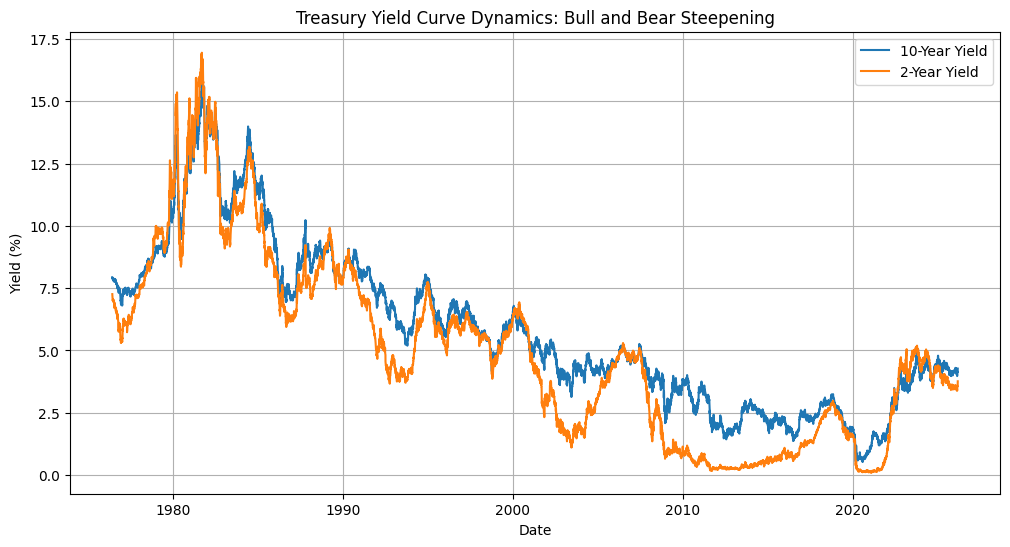

In [22]:
plt.figure(figsize=(12,6))

plt.plot(df.index, df["10Y"], label="10-Year Yield")
plt.plot(df.index, df["2Y"], label="2-Year Yield")

plt.title("Treasury Yield Curve Dynamics: Bull and Bear Steepening")
plt.xlabel("Date")
plt.ylabel("Yield (%)")
plt.legend()
plt.grid()

plt.show()

10Y–2Y Spread vs S&P 500

In [23]:
# Correct S&P 500 series from FRED
sp500 = fred.get_series('SP500', observation_start='1950-01-01')  # adjust start date
sp500 = sp500.dropna()

# Combine with yields using intersection of dates
df = pd.DataFrame({
    "2Y": y2,
    "10Y": y10
}).dropna()

# Restrict S&P 500 to the same dates as yields
df = df.join(sp500.rename("SP500"), how="inner")

# Spread
df["Spread"] = df["10Y"] - df["2Y"]

df.head()

,2Y,10Y,SP500,Spread
2016-03-14,0.97,1.97,2019.64,1.00
2016-03-15,0.98,1.97,2015.93,0.99
2016-03-16,0.87,1.94,2027.22,1.07
2016-03-17,0.87,1.91,2040.59,1.04
2016-03-18,0.84,1.88,2049.58,1.04


Analysis

The yield curve steepens when the spread between long-term and short-term
interest rates increases. Two distinct types of steepening can be observed.

Bull steepening typically occurs during economic downturns. During the
2008 financial crisis, long-term yields declined faster than short-term
yields as investors anticipated aggressive monetary easing by the Federal
Reserve. The Fed reduced policy rates to near zero, causing short-term
rates to fall while long-term rates reflected expectations of recovery.

Bear steepening usually occurs during economic expansions or inflationary
periods. During the post-COVID recovery in 2020–2021, long-term yields
rose significantly as markets anticipated stronger growth and inflation,
while short-term rates remained low due to accommodative monetary policy.

The 10-year minus 2-year spread is particularly important because
historical inversions (negative spread) have preceded U.S. recessions.
When we compare this spread with the S&P 500, we observe that equity
markets often experience volatility when the spread narrows or turns
negative, reflecting rising recession risk.

Conclusion

Through hands-on analysis using Python and FRED data, we examined the behavior of the U.S. yield curve and its relationship with broader economic conditions.

Key findings:

Open government data enables transparent economic research.

The slope of the yield curve reflects expectations about growth and monetary policy.

Yield curve steepening can be classified as bull or bear depending on underlying rate movements.

The 10Y–2Y spread remains one of the most reliable recession indicators.

In [24]:
import os
os.makedirs("images", exist_ok=True)
plt.savefig("images/bull_bear_steepening.png")
plt.savefig("images/sp500_vs_spread.png")

<Figure size 640x480 with 0 Axes>